# XGBFR 03 — Operational Trade-off

Focus explicitly on False Negatives because missing a real Peak is operationally more costly than generating a false alert.

In [1]:
# Import libraries
from pathlib import Path
import sys

import yaml
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "peak_risk_final_refinement.yaml"
)
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/peak_risk_final_refinement.yaml')

In [3]:
# Import module for Final Refinement Analysis
from src.ontario_peak_risk.models.peak_risk.final_refinement.analysis import (
    threshold_grid,
    threshold_sweep,
    fold_threshold_summary,
)
from src.ontario_peak_risk.models.peak_risk.final_refinement.plotting import (
    false_negative_tradeoff,
)

In [4]:
# 
with CONFIG_PATH.open("r", encoding="utf-8") as handle:
    CONFIG = yaml.safe_load(handle)

predictions = pd.read_parquet(
    PROJECT_ROOT / CONFIG["paths"]["validation_predictions"]
)

thresholds = threshold_grid(
    CONFIG["threshold_analysis"]["min_threshold"],
    CONFIG["threshold_analysis"]["max_threshold"],
    CONFIG["threshold_analysis"]["step"],
)

fold_sweep = threshold_sweep(predictions, thresholds, ["fold"])
fold_summary = fold_threshold_summary(fold_sweep)

display(
    fold_summary[
        [
            "threshold",
            "min_precision",
            "min_recall",
            "worst_fold_f1",
            "max_missed_peak_rate_pct",
            "mean_false_alarm_rate_pct",
        ]
    ]
)


,threshold,min_precision,min_recall,worst_fold_f1,max_missed_peak_rate_pct,mean_false_alarm_rate_pct
0,0.02,0.194633,0.725789,0.325249,27.421144,13.945618
1,0.03,0.215181,0.683394,0.353194,31.660638,12.029609
2,0.04,0.231365,0.651793,0.374459,34.820684,10.779451
3,0.05,0.244794,0.627319,0.391601,37.268107,9.866620
4,0.06,0.256558,0.607274,0.406245,39.272588,9.159496
...,...,...,...,...,...,...
84,0.86,0.683851,0.156306,0.264685,84.369404,0.644003
85,0.87,0.693199,0.149259,0.254799,85.074053,0.592211
86,0.88,0.703650,0.141619,0.243839,85.838148,0.539583
87,0.89,0.714076,0.133811,0.232406,86.618917,0.486643


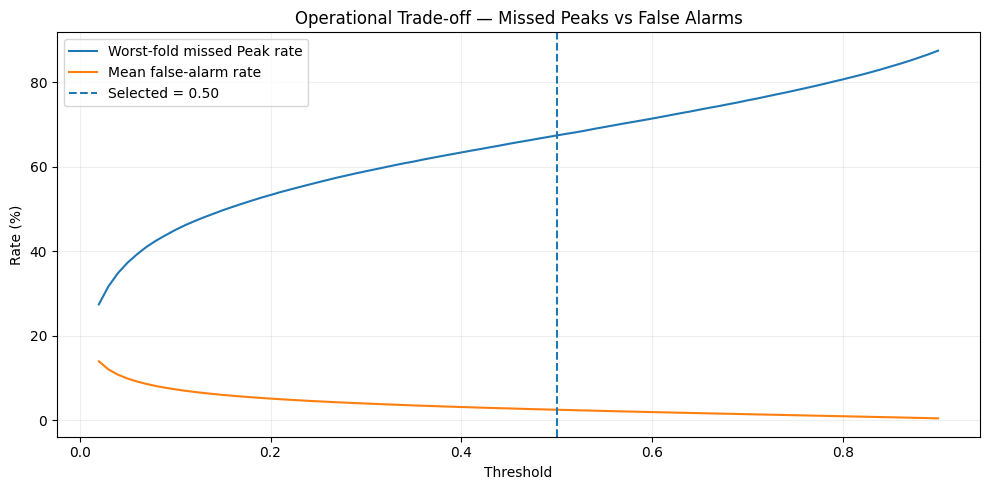

In [6]:
# This figure does not select the threshold yet; it visualizes
# the operational cost trade-off.
fig = false_negative_tradeoff(fold_summary, 0.50)
plt.show()
